✅  Loaded student_raw.csv  →  shape: (395, 33)

  3.1  MISSING VALUES
  ✅  No missing values found in any column.


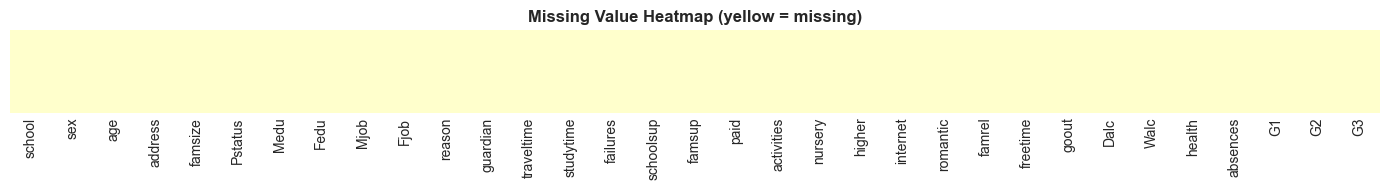

  Plot saved → ../docs/missing_values_heatmap.png

  3.2  DUPLICATES
  Duplicate rows: 0
  ✅  No duplicates.

  3.3  OUTLIER INSPECTION (boxplots)


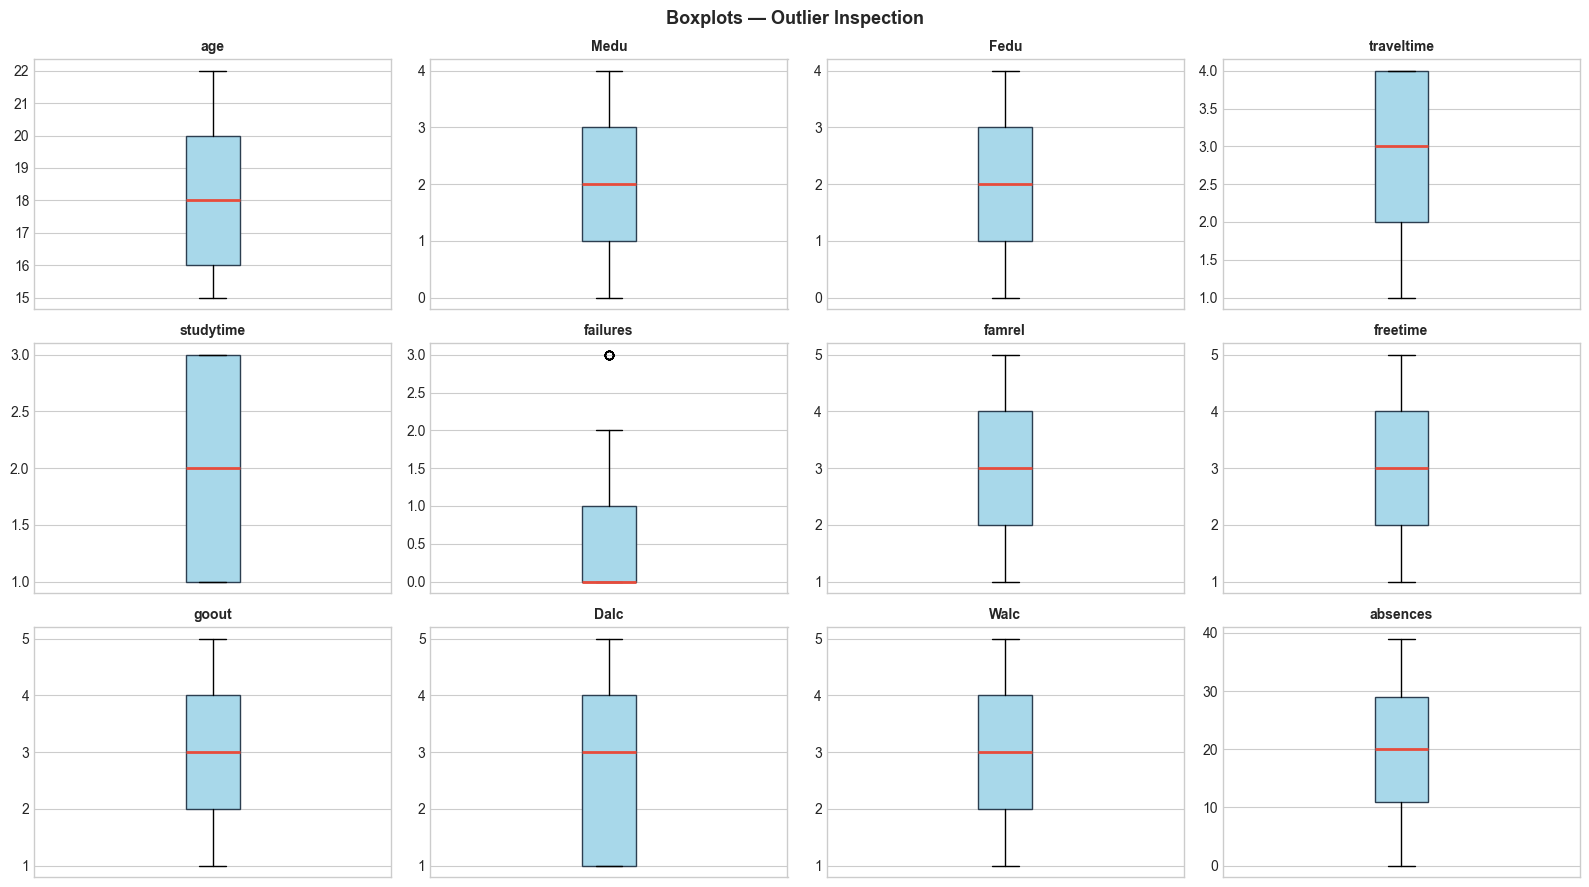

  Plot saved → ../docs/outlier_boxplots.png
  Note: High absences are legitimate — kept as-is.

  3.4  TARGET VARIABLE
  pass = 1  (Pass) : 117  (29.6%)
  pass = 0  (Fail) : 278  (70.4%)


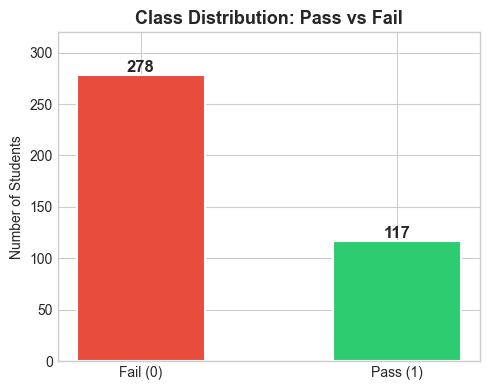

  Plot saved → ../docs/class_distribution.png

  3.5  ENCODING CATEGORICAL VARIABLES
  Binary encoded  : ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
  Label encoded   : ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian']

  ✅  All columns are now numeric.
  Final shape     : (395, 34)

✅  Stage 3 complete.
    Saved : ../data/student_processed.csv
    Next  : python stage4_eda.py  (Aparna)


In [1]:
# =============================================================================
# STAGE 3 — Data Preprocessing & Cleaning
# -----------------------------------------------------------------------------
# Project: Student Performance Prediction & Early Intervention (#23)
# Team   : Abhi | Aparna | Jia  |  Predictive Analytics 2025-26
# Run    : python stage3_preprocessing.py   (after stage2)
# Input  : ../data/student_raw.csv
# Output : ../data/student_processed.csv   (used by Aparna in Stage 4)
# =============================================================================

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

DOCS_DIR = "../docs"
os.makedirs(DOCS_DIR, exist_ok=True)


# ── Load from Stage 2 output ──────────────────────────────────────────────────
def load_raw_data():
    path = "../data/student_raw.csv"
    if not os.path.exists(path):
        raise FileNotFoundError(
            "student_raw.csv not found.\n"
            "Please run stage2_data_collection.py first."
        )
    df = pd.read_csv(path)
    print(f"✅  Loaded student_raw.csv  →  shape: {df.shape}")
    return df


# ── 3.1  Missing Value Check ──────────────────────────────────────────────────
def check_missing(df):
    print("\n" + "=" * 50)
    print("  3.1  MISSING VALUES")
    print("=" * 50)
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("  ✅  No missing values found in any column.")
    else:
        print(missing[missing > 0].to_string())

    # Heatmap
    fig, ax = plt.subplots(figsize=(14, 2))
    sns.heatmap(df.isnull(), cbar=False, ax=ax,
                yticklabels=False, cmap="YlOrRd")
    ax.set_title("Missing Value Heatmap (yellow = missing)",
                 fontweight="bold")
    plt.tight_layout()
    out = f"{DOCS_DIR}/missing_values_heatmap.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {out}")


# ── 3.2  Duplicate Check ──────────────────────────────────────────────────────
def check_duplicates(df):
    print("\n" + "=" * 50)
    print("  3.2  DUPLICATES")
    print("=" * 50)
    dups = df.duplicated().sum()
    print(f"  Duplicate rows: {dups}")
    if dups > 0:
        df = df.drop_duplicates()
        print(f"  ✅  Dropped. New shape: {df.shape}")
    else:
        print("  ✅  No duplicates.")
    return df


# ── 3.3  Outlier Inspection ───────────────────────────────────────────────────
def check_outliers(df):
    print("\n" + "=" * 50)
    print("  3.3  OUTLIER INSPECTION (boxplots)")
    print("=" * 50)
    key_num = ["age","Medu","Fedu","traveltime","studytime","failures",
               "famrel","freetime","goout","Dalc","Walc","absences"]

    fig, axes = plt.subplots(3, 4, figsize=(16, 9))
    axes = axes.flatten()
    for i, col in enumerate(key_num):
        axes[i].boxplot(
            df[col], patch_artist=True,
            boxprops=dict(facecolor="#a8d8ea", color="#2c3e50"),
            medianprops=dict(color="#e74c3c", linewidth=2)
        )
        axes[i].set_title(col, fontweight="bold", fontsize=10)
        axes[i].set_xticks([])
    plt.suptitle("Boxplots — Outlier Inspection",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    out = f"{DOCS_DIR}/outlier_boxplots.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {out}")
    print("  Note: High absences are legitimate — kept as-is.")


# ── 3.4  Create Target Variable ───────────────────────────────────────────────
def create_target(df):
    print("\n" + "=" * 50)
    print("  3.4  TARGET VARIABLE")
    print("=" * 50)
    df["pass"] = (df["G3"] >= 10).astype(int)
    counts = df["pass"].value_counts()
    total  = len(df)
    print(f"  pass = 1  (Pass) : {counts[1]}  ({counts[1]/total*100:.1f}%)")
    print(f"  pass = 0  (Fail) : {counts[0]}  ({counts[0]/total*100:.1f}%)")

    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(["Fail (0)", "Pass (1)"], counts.values,
                  color=["#e74c3c", "#2ecc71"],
                  edgecolor="white", linewidth=1.5, width=0.5)
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 3,
                str(cnt), ha="center", fontsize=12, fontweight="bold")
    ax.set_title("Class Distribution: Pass vs Fail",
                 fontweight="bold", fontsize=13)
    ax.set_ylabel("Number of Students")
    ax.set_ylim(0, counts.max() * 1.15)
    plt.tight_layout()
    out = f"{DOCS_DIR}/class_distribution.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {out}")
    return df


# ── 3.5  Encode Categorical Variables ────────────────────────────────────────
def encode_features(df):
    print("\n" + "=" * 50)
    print("  3.5  ENCODING CATEGORICAL VARIABLES")
    print("=" * 50)
    df_processed = df.copy()

    # yes/no → 1/0
    binary_cols = ["schoolsup","famsup","paid","activities",
                   "nursery","higher","internet","romantic"]
    for col in binary_cols:
        df_processed[col] = (df_processed[col] == "yes").astype(int)
    print(f"  Binary encoded  : {binary_cols}")

    # Remaining categoricals → label encode
    cat_cols = ["school","sex","address","famsize","Pstatus",
                "Mjob","Fjob","reason","guardian"]
    le = LabelEncoder()
    for col in cat_cols:
        df_processed[col] = le.fit_transform(df_processed[col])
    print(f"  Label encoded   : {cat_cols}")

    print("\n  ✅  All columns are now numeric.")
    print(f"  Final shape     : {df_processed.shape}")
    return df_processed


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df = load_raw_data()
    check_missing(df)
    df = check_duplicates(df)
    check_outliers(df)
    df = create_target(df)
    df_processed = encode_features(df)

    # Save for Aparna (Stage 4 onwards)
    out_path = "../data/student_processed.csv"
    df_processed.to_csv(out_path, index=False)
    print(f"\n✅  Stage 3 complete.")
    print(f"    Saved : {out_path}")
    print("    Next  : python stage4_eda.py  (Aparna)")
